# **Business Problem**
A Bank in Portugal have recorded the data of their previous campaign. This time instead of following traditional route, the business wants to make informed decision to target the right customers and maximize lead conversion.

They were looking for a data scientist and hired me to analyze their data and craete a predictive model that enables them to rightly identify leads with customer potentiality, so that they can focus their resources on converting them into their real customer. With this they want to save time and resources by doing concise targeted telemarketing.
<br>
<br>

---



# **Objective**
This project is a marketing lead conversion prediction project. The objective of this project is to build a Machine Learning pipeline to train algorithms and find the best model to predict the likeliness of a lead converting to bank's customer by subscribing to their Term Deposit.
<br><br>


---



# **Importing Modules**

In [1]:
#Importing Pandas and Numpy
import pandas as pd
import numpy as np

#Imports for Pre Processing and Feature Engineering
from sklearn.model_selection import (train_test_split, RandomizedSearchCV, StratifiedKFold)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

#Imports for Supervised Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

#Imports for Pipeline and Transformation
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#Imports for Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Imports for Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)

# **Data Collection**
The data was collected from UCI Machine Learning Repository, downloaded and uploaded to my github for easy access.

The dataset was given in two sets, one with a full version (file name: bank-full.csv) and another as a sample size (file name: bank.csv).
<br><br>
**[Original Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing)** || **[Github Link](https://github.com/koderlad/dataset-introtoai)**

In [2]:
#Load Data and save it as a DataFrame.
df = pd.read_csv('https://raw.githubusercontent.com/koderlad/dataset-introtoai/refs/heads/main/bank.csv')

*Note: Full dataset took large amount of time to train and therefore I am using sample dataset.*

In [4]:
df.shape

(4521, 17)

# **Splitting Data**

In [5]:
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42, stratify=df['y'])
print("Training Data Size: ", df_train.shape)
print("Testing Data Size: ", df_test.shape)

Training Data Size:  (3164, 17)
Testing Data Size:  (1357, 17)


# **Exploratory Analysis**

## **Data Info**


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3164 entries, 1244 to 3187
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        3164 non-null   int64 
 1   job        3164 non-null   object
 2   marital    3164 non-null   object
 3   education  3164 non-null   object
 4   default    3164 non-null   object
 5   balance    3164 non-null   int64 
 6   housing    3164 non-null   object
 7   loan       3164 non-null   object
 8   contact    3164 non-null   object
 9   day        3164 non-null   int64 
 10  month      3164 non-null   object
 11  duration   3164 non-null   int64 
 12  campaign   3164 non-null   int64 
 13  pdays      3164 non-null   int64 
 14  previous   3164 non-null   int64 
 15  poutcome   3164 non-null   object
 16  y          3164 non-null   object
dtypes: int64(7), object(10)
memory usage: 444.9+ KB


In [7]:
df_train.duplicated().value_counts()

,count
False,3164


## **Understanding the Numerical and Categorical data**

### **Numerical Data**

In [8]:
df_train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000,3164.000000
mean,41.054678,1406.905499,16.050885,265.302149,2.798357,39.932364,0.515803
std,10.386760,2810.333965,8.222576,263.214008,3.128472,100.104153,1.490216
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,64.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,452.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,48.000000,1490.000000,21.000000,332.000000,3.000000,-1.000000,0.000000
max,87.000000,42045.000000,31.000000,3025.000000,50.000000,871.000000,22.000000



### **My Observation and Reasoning**
**pdays** can be converted to "contacted_before" for more sensible data explanation.
<br><br>
"**previous**" and "**campaign**" represents behavior of bank telemarketers. Data can be skewed but represents a real value.
<br><br>
"**age**" shows realistic values with no negative or extreme high values.
<br><br>
"**balance**" is highly skewed, but it seems explainable to me of someone having higher income and some with lower and in credit.
<br><br>
"**duration**" is a value that is only known after the outcome removing to avoid data leakage.

In [9]:
#Checking for unique values in each of the Categorical Fields.
cat_col = []
for col in df_train.columns:
  if df_train[col].dtypes == 'object':
    cat_col.append(col)
    print(f"{col.upper()}'s unique values are: \n'", df_train[col].unique())

JOB's unique values are: 
' ['entrepreneur' 'unemployed' 'retired' 'housemaid' 'management' 'services'
 'self-employed' 'admin.' 'blue-collar' 'student' 'technician' 'unknown']
MARITAL's unique values are: 
' ['single' 'married' 'divorced']
EDUCATION's unique values are: 
' ['tertiary' 'secondary' 'unknown' 'primary']
DEFAULT's unique values are: 
' ['no' 'yes']
HOUSING's unique values are: 
' ['yes' 'no']
LOAN's unique values are: 
' ['yes' 'no']
CONTACT's unique values are: 
' ['cellular' 'unknown' 'telephone']
MONTH's unique values are: 
' ['nov' 'jul' 'feb' 'may' 'apr' 'jan' 'jun' 'mar' 'dec' 'aug' 'oct' 'sep']
POUTCOME's unique values are: 
' ['unknown' 'other' 'failure' 'success']
Y's unique values are: 
' ['no' 'yes']


Based on the data description, this features measures the "failure" or "success" of previous campaing. If the result is not know it is marked as "unknown".

# **Data Imbalance Check**

<Axes: title={'center': 'Target Class Distribution'}, xlabel='Target', ylabel='Count'>

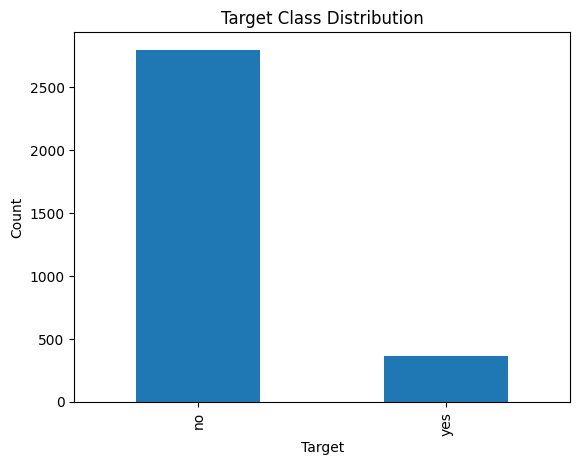

In [11]:
df_train["y"].value_counts().plot(kind="bar", title="Target Class Distribution", xlabel="Target", ylabel="Count")

# **Droping "duration" Column**

In [13]:
df_train.drop(columns=["duration"], inplace=True)
df_test.drop(columns=["duration"], inplace=True)

# **Feature Engineering**

## **Create "contacted_before" feature**


In [14]:
#For Training Data
df_train['contacted_before'] = (df_train['pdays'] > -1).astype('int')
df_train.drop(columns = ['pdays'], inplace=True)

In [15]:
#For Test Data
df_test['contacted_before'] = (df_test['pdays'] > -1).astype('int')
df_test.drop(columns = ['pdays'], inplace=True)

## **Mapping Binary Data**

In [16]:
#Selecting Categorical Columns
cat_features = df_train.select_dtypes(include=["object"]).columns.tolist()

In [17]:
#Selecting Numerical Columns
num_features = df_train.select_dtypes(include=["int64"]).columns.tolist()

Removing "**contacted_before**" from this list as it already in "0" and "1".

In [18]:
num_features.remove("contacted_before")

In [19]:
#Separating Binary columns
bin_cat_features = ["default", "housing", "loan", "y"]
nonbin_cat_features = [col for col in cat_features if col not in bin_cat_features]

In [20]:
for col in bin_cat_features:
  #For Training Data
  df_train[col] = df_train[col].map({'yes': 1, 'no': 0})
  #For Testing Data
  df_test[col] = df_test[col].map({'yes': 1, 'no': 0})

## **Target and Predictor Variables**

In [21]:
#Training Features
X_train = df_train.drop(['y'], axis=1)
y_train = df_train['y']

In [22]:
#Test Features
X_test = df_test.drop(['y'], axis=1)
y_test = df_test['y']

## **Encoding and Scaling**

### **Scaling Numerical Data**

In [23]:
num_tf = Pipeline(steps = [("scaler", StandardScaler())])

### **Encoding Categorical Data**

In [24]:
cat_tf = Pipeline(steps = [("onehot", OneHotEncoder(handle_unknown="ignore"))])

In [25]:
#PreProcessing Pipeline
preprocessor = ColumnTransformer(
    transformers = [
        ("num", num_tf, num_features),
        ("cat", cat_tf, nonbin_cat_features)
    ]
)

## **Model Training and Hyperparameter Fine Tuning**

### **Models**

In [27]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter = 2000,
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_jobs=-1,
        random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=42
    ),
    "SVM": SVC(
        probability = True,
        random_state = 42
    )
}

### **Parameter Distribution**

In [64]:
param_distributions = {
    "LogisticRegression": {
        "model__C": np.logspace(0, 10, 10),
        "model__solver": ['lbfgs', 'newton-cholesky', 'sag'],
    },
    "RandomForest": {
        "model__n_estimators": [100, 200, 350],
        "model__criterion": ['gini', 'entropy'],
        "model__max_depth": [None, 15],
        "model__min_samples_leaf": [2, 10],
        "model__max_features": ["sqrt", 'log2']
    },
    "DecisionTree": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [15, None],
        "model__min_samples_split": [2, 10],
        "model__min_samples_leaf": [1, 5]
    },
    "SVM": {
        "model__C": np.linspace(1, 10, 4),
        "model__kernel": ["sigmoid", "rbf", "linear"]
    }
}

### **Cross Validation**

In [65]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# **Model Training**

Using **Randomized Search CV** instead of **Grid Search CV** to save processing resource cost and time.

In [30]:
search_results = []
best_estimators = {}

for model_name, model in models.items():
   print(f"Training model: {model_name}")

   pipeline = Pipeline(steps=[
       ("preprocessor", preprocessor),
       ("smote", SMOTE(random_state=42)),
       ("model", model)
   ])

   random_search = RandomizedSearchCV(
       estimator=pipeline,
       param_distributions=param_distributions[model_name],
       scoring={"f1": "f1", "accuracy": "accuracy"},
       cv=cv_strategy,
       n_jobs=-1,
       n_iter=12,
       random_state=42,
       error_score="raise",
       refit="f1"
   )

   random_search.fit(X_train, y_train)

   best_estimators[model_name] = random_search.best_estimator_

   search_results.append({
       "Model": model_name,
       "Best Score": random_search.best_score_,
       "Best Parameters": random_search.best_params_,
       "Results": random_search.cv_results_
   })

Training model: LogisticRegression
Training model: RandomForest
Training model: DecisionTree
Training model: SVM


In [31]:
results_df = pd.DataFrame(search_results).sort_values("Best Score", ascending=False).reset_index(drop=True)

,Model,Best Score,Best Parameters,Results
0,RandomForest,0.343997,"{'model__n_estimators': 200, 'model__min_sampl...","{'mean_fit_time': [1.8118355751037598, 3.81404..."
1,SVM,0.315925,"{'model__kernel': 'rbf', 'model__C': 1.0}","{'mean_fit_time': [10.694936227798461, 10.3917..."
2,LogisticRegression,0.304350,"{'model__solver': 'newton-cholesky', 'model__C...","{'mean_fit_time': [0.17208380699157716, 0.1658..."
3,DecisionTree,0.282968,"{'model__min_samples_split': 2, 'model__min_sa...","{'mean_fit_time': [0.15049219131469727, 0.1409..."


In [32]:
best_model_name = results_df.loc[0, "Model"]
best_model = best_estimators[best_model_name]
print("Best Model: ", best_model_name)

In [33]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [34]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "Average Precision": average_precision_score(y_test, y_proba)
}

In [35]:
metrics_df = pd.DataFrame(metrics.items(), columns=["Metric", "Score"])
display(metrics_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

,Metric,Score
0,Accuracy,0.860722
1,Precision,0.342857
2,Recall,0.230769
3,F1-score,0.275862
4,ROC-AUC,0.723932
5,Average Precision,0.303510



Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1201
           1       0.34      0.23      0.28       156

    accuracy                           0.86      1357
   macro avg       0.62      0.59      0.60      1357
weighted avg       0.84      0.86      0.85      1357



The above classification report suggests that the model is good at predicting "No" and bad at predicting "Yes". The precision (0.34) for model predicting "Yes" is low, recall (0.23) identifies less correct class.

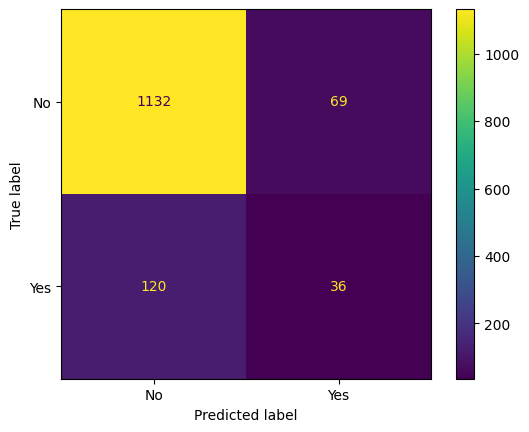

In [36]:
cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["No", "Yes"])
cm.plot()

## **Threshold Optimization**

In [39]:
thresholds = np.arange(0.1, 0.9, 0.001)
f1_scores = []
recalls = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))
    recalls.append(recall_score(y_test, y_pred_t))

best_idx = np.argmax(f1_scores)

print("Best Threshold:", thresholds[best_idx])
print("Best F1:", f1_scores[best_idx])
print("Recall at best:", recalls[best_idx])

Best Threshold: 0.4360000000000003
Best F1: 0.38202247191011235
Recall at best: 0.4358974358974359


In [40]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

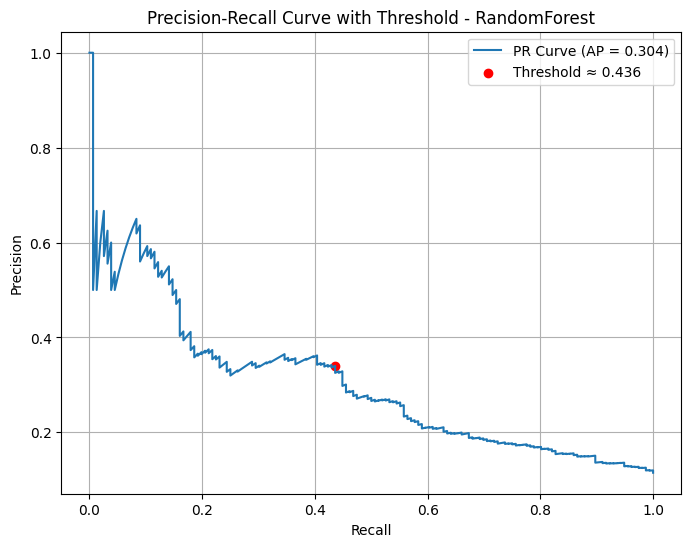

At threshold 0.436:
Precision: 0.340
Recall: 0.436


In [41]:
chosen_threshold = 0.436

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR Curve (AP = {avg_precision:.3f})")

idx = np.argmin(np.abs(pr_thresholds - chosen_threshold))
plt.scatter(recall[idx], precision[idx], color="red", label=f"Threshold ≈ {chosen_threshold}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve with Threshold - {best_model_name}")
plt.legend()
plt.grid()

plt.show()

print(f"At threshold {chosen_threshold}:")
print(f"Precision: {precision[idx]:.3f}")
print(f"Recall: {recall[idx]:.3f}")

The threshold value of "0.436" gives the best trade-off between recall and precision. <br><br>

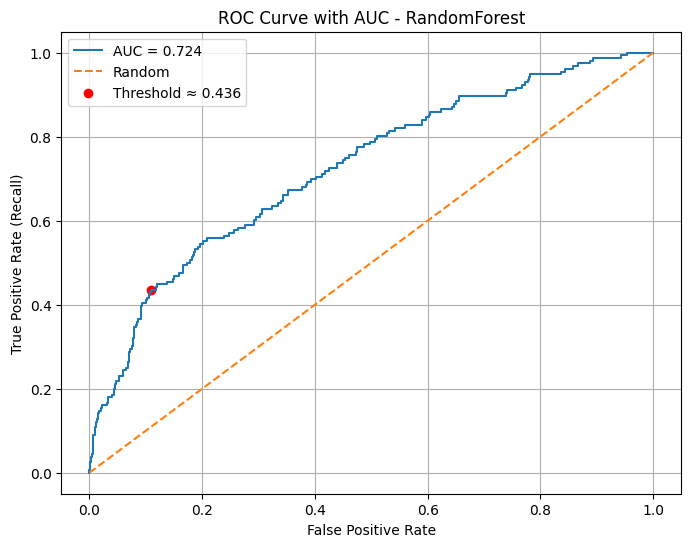

At threshold 0.436:
TPR (Recall): 0.436
FPR: 0.110
ROC-AUC Score: 0.724


In [42]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)

roc_auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

idx = np.argmin(np.abs(roc_thresholds - chosen_threshold))
plt.scatter(fpr[idx], tpr[idx], color="red", label=f"Threshold ≈ {chosen_threshold}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title(f"ROC Curve with AUC - {best_model_name}")
plt.legend()
plt.grid()

plt.show()

print(f"At threshold {chosen_threshold}:")
print(f"TPR (Recall): {tpr[idx]:.3f}")
print(f"FPR: {fpr[idx]:.3f}")
print("ROC-AUC Score:", round(roc_auc, 3))

ROC-AUC value is 0.724, it performs slightly well with adjusted thresholds and improved recall. While it is not the best performance but it is also not random.

## **Confusion Matrix with Fine Tuned Threshold**

In [49]:
y_pred_tuned = (y_proba >= chosen_threshold).astype(int)
cm_before = confusion_matrix(y_test, y_pred)
cm_after = confusion_matrix(y_test, y_pred_tuned)

In [52]:
classes = best_model.classes_.tolist()
classes = list(map(lambda x: "No" if x==0 else "Yes", classes))

Text(0.5, 1.0, 'Confusion Matrix (t=0.436)')

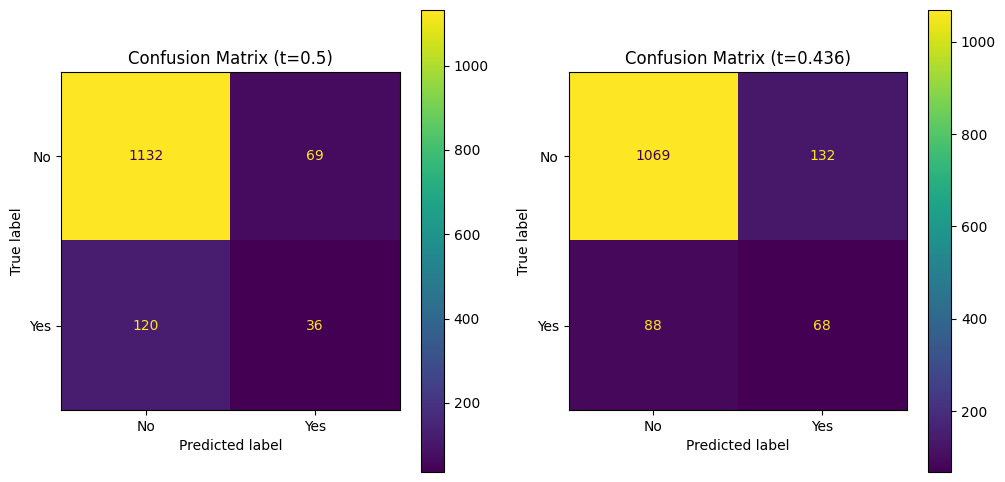

In [59]:
fig, axes = plt.subplots(1, 2, figsize = (12, 6))
disp1 = ConfusionMatrixDisplay(cm_before, display_labels=classes)
disp1.plot(ax=axes[0], values_format="d")
axes[0].set_title("Confusion Matrix (t=0.5)")

disp2 = ConfusionMatrixDisplay(cm_after, display_labels=classes)
disp2.plot(ax=axes[1], values_format="d")
axes[1].set_title("Confusion Matrix (t=0.436)")

The model has improved in predicting correct outcome by almost double (from 36 to 68). It also decreased False Negative value (from 120 to 88)<br>
While the False Positive (132) has increased.

# **Measuring Feature Importance**

In [60]:
#Extracting the trained best model
rf_model = best_model["model"]
importances = rf_model.feature_importances_

In [61]:
#Getting Feature names after preprocessing.
#We only need to get the Categorical Non-Binary features because others stay same, only encoded ones gets changed.
ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(nonbin_cat_features)
feature_names = list(num_features) + list(encoded_cat_features)

In [62]:
#Only getting the top 10 features
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

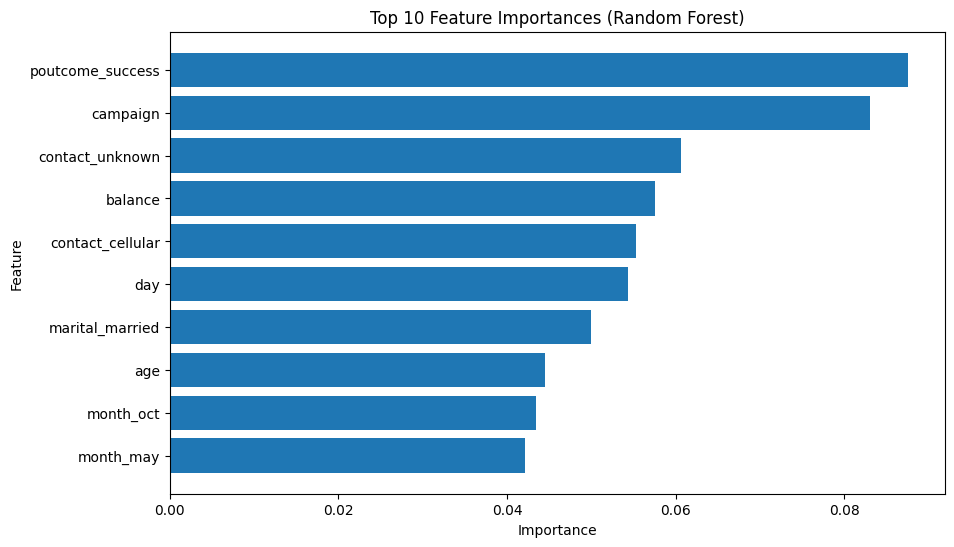

In [63]:
top_features = feature_importance_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances (Random Forest)")

plt.show()

The above diagram suggests that "Previous Success" and "Balance" has the most importance in the prediction along with "campaign".

###### **What does this mean for business?**
The business shoukd prioritize customer's previous campaign outcome, previous subscription means likely new subscription.

"Campaign" suggests that follow-up is important for conversion.

# **Final Discussion**

##### **Strengths**
1.   The pipeline is built following the standard data science process.
2.   Best Model was further optimized for best outcome, using Threshold Optimization.
3. The pipeline used real-world data of a Portuguese Bank Marketing Campaign. This project has practical implicatioins because it is solving real-world business problem.
4. In this project, a careful consideration is given to understanding "**outliers**", "**features**" and its "**importance**". Features like "**duration**" and "**pdays**" was removed to prevent any data-leakage and it would influence the future outcome.
5. Good feature engineering is performed by understanding the data, for example "**pdays**" was replaced by "**previously_contacted**" which explained the data in a better context.
6. Class imbalance was handled using SMOTE to avoid overfitting/underfiting problem.
7. The model was comprehensively evaluated using robust metrices like F1-Score, Recall, Precision, AUC and Confusion Matrix.
8. Important Features were visualized to help business prioritize high impact data points.

##### **Limitations**
1. The low AUC suggests that model was only able to moderately separate classes. <br>
2. Even after threshold optimization model was only able to capture 43.6% of actual customers<br>
3. Improving recall lead to the increase in False Positve Rates.
4. Some data was not clearly explainable like "previous" and "balance" raising questions about why they had extreme outliers.

##### **Business Implications**
For business, the model provides valuable but imperfect insights for decision making.
- The model can provide recommendations for customers more likely to subscribe, improving the efficiency of marketing campaigns.
- Increased recall means that more potential customers are identified.
- However, the increase in False Positive means that some customers who might not be converted will still be contacted increasing operational cost by slight margin.

##### **Data-Driven Recommendation**
My data-driven recommendation for this model based on the results are:
- Use this model as a recommendation-system to rank potential customer based on the probability of prediction and not a decisive system.
- Adopt threshold optimization based on business needs, lower threshold for to prioritize maximum conversion ann higher threshold to reduce operational cost.
- Adding high value features like "monthly salary", "transactional records", "monthly fixed emi" among few others could add more value and improve model performance.
- Focus on high impact features like "previous success", "follow-up rate (campaign)" and "balance".

##### **Deployment**
This model can be deployed but should be used as a recommendation-system to rank the likelihood of customer conversion. Simultaneously, more explainable features should be added to this data so that model can be trained to improve its performance.